# ReproScore — Analysis Notebook

Reproduces all statistics and figures for the 423-repository evaluation of the ReproScore framework.

**Author**: Sheeba Samuel · sheeba.samuel@informatik.tu-chemnitz.de · Chemnitz University of Technology  
**Repository**: https://github.com/myVSR/reproscore  
**Run ID (bundled dataset)**: `20260511_101920`

Run from the repository root:
```bash
jupyter notebook notebooks/reproscore_ablation_analysis.ipynb
```

All statistics are also reproducible via the standalone script:
```bash
python ablation_analysis.py
```


In [1]:
# Install required libraries
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
    'pandas>=1.5.0', 'numpy>=1.23.0', 'scipy>=1.10.0',
    'matplotlib>=3.6.0', 'seaborn>=0.12.0', 'PyYAML>=6.0'],
    stdout=subprocess.DEVNULL)
print('Libraries ready.')

Libraries ready.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: /home/ti89cos/.pyenv/versions/3.11.0/bin/python3 -m pip install --upgrade pip


In [2]:
import os, sys
from pathlib import Path

# Ensure working directory is the repo root regardless of where notebook is launched
repo_root = Path(__file__).parent.parent if '__file__' in dir() else Path.cwd()
if (repo_root / 'data').exists():
    pass
elif (repo_root.parent / 'data').exists():
    repo_root = repo_root.parent
os.chdir(repo_root)
sys.path.insert(0, str(repo_root))
print(f'Working directory: {Path.cwd()}')

Working directory: /home/ti89cos/ti89cos_reproscore/reproscore


In [3]:
from __future__ import annotations
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

plt.rcParams.update({'figure.dpi': 150, 'font.size': 11})
FIGURES = Path('notebooks/results')
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load data

In [4]:
def _latest_run() -> Path:
    base = Path('data/ablation')
    runs = sorted(
        [d for d in base.iterdir()
         if d.is_dir() and (d / 'provenance.json').exists()]
    )
    if not runs:
        raise FileNotFoundError(f'No completed run found in {base}')
    return runs[-1]


def auc_mwu(scores: np.ndarray, labels: np.ndarray) -> float:
    """AUC via Mann-Whitney U (no sklearn dependency)."""
    scores = np.asarray(scores, dtype=float)
    labels = np.asarray(labels, dtype=int)
    pos, neg = scores[labels == 1], scores[labels == 0]
    if len(pos) == 0 or len(neg) == 0:
        return float('nan')
    u = sum((p > neg).sum() + 0.5 * (p == neg).sum() for p in pos)
    return float(u) / (len(pos) * len(neg))


def gate(x: np.ndarray, tau: float, k: float) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return np.where(x >= tau, x / 100.0, (x / tau) ** k * tau / 100.0)


run_dir = _latest_run()
df = pd.read_csv(run_dir / 'scores.csv')
prov = json.loads((run_dir / 'provenance.json').read_text())

print(f'Run ID : {run_dir.name}')
print(f'Repos  : {len(df)}')
df['failure_mode'].value_counts()

Run ID : 20260511_101920
Repos  : 423


failure_mode
code_error        85
install_dep       85
missing_module    85
missing_data      84
success           84
Name: count, dtype: int64

In [5]:
# Constants
FAILURE_MODES = ['success', 'install_dep', 'missing_module', 'missing_data', 'code_error']
CATS = [('E', 0.30, 40, 1.5), ('A', 0.25, 30, 1.5),
        ('D', 0.20, 20, 1.2), ('C', 0.15, 25, 1.2), ('S', 0.10, 30, 1.2)]
CAT_NAMES = {'E': 'Environment', 'A': 'Data Access.', 'D': 'Documentation',
             'C': 'Code Quality', 'S': 'Repro. Signals'}
MODE_COLORS = {
    'success':        '#2ecc71',
    'install_dep':    '#e74c3c',
    'missing_module': '#e67e22',
    'missing_data':   '#3498db',
    'code_error':     '#9b59b6',
}

y = (df['failure_mode'] == 'success').astype(int)
total_penalty = df['penalty_E'] + df['penalty_A'] + df['penalty_seed']
sub_cols = sorted(c for c in df.columns if c.startswith('sub_'))

## 2. Category means by failure mode (Table 2)

In [6]:
rows = []
for mode in FAILURE_MODES:
    sub = df[df['failure_mode'] == mode]
    row = {'Failure mode': mode, 'n': len(sub)}
    for c, *_ in CATS:
        row[CAT_NAMES[c]] = sub[f'cat_{c}_raw'].mean().round(1)
    row['RRS'] = sub['rrs'].mean().round(1)
    rows.append(row)

table2 = pd.DataFrame(rows).set_index('Failure mode')
print('Table 2: Category means by failure mode')
table2

Table 2: Category means by failure mode


,n,Environment,Data Access.,Documentation,Code Quality,Repro. Signals,RRS
Failure mode,,,,,,,
success,84,10.3,23.0,28.5,68.4,54.2,14.6
install_dep,85,22.8,27.6,37.8,74.6,56.3,26.8
missing_module,85,5.2,20.3,22.9,62.2,40.3,7.0
missing_data,84,4.4,17.0,19.3,61.5,41.9,6.4
code_error,85,11.0,24.1,28.7,67.4,49.0,14.3


## 3. Figure: Category score distributions by failure mode (violin)

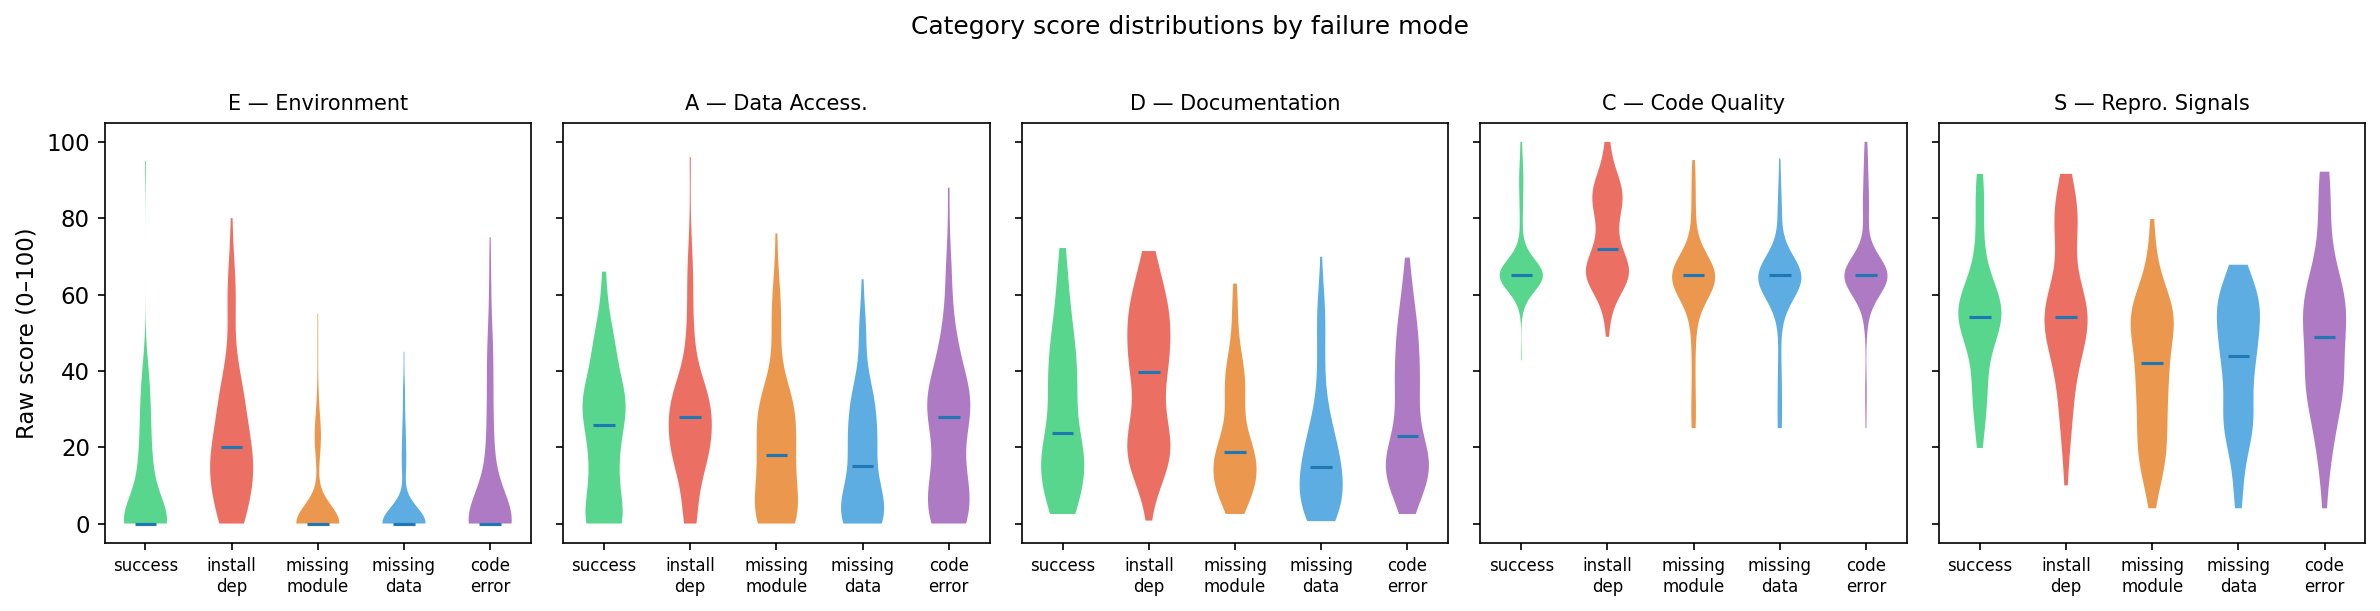

In [7]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)

for ax, (cat, *_) in zip(axes, CATS):
    data_by_mode = [df[df['failure_mode'] == m][f'cat_{cat}_raw'].values
                    for m in FAILURE_MODES]
    vp = ax.violinplot(data_by_mode, showmedians=True, showextrema=False)
    for i, (patch, mode) in enumerate(zip(vp['bodies'], FAILURE_MODES)):
        patch.set_facecolor(MODE_COLORS[mode])
        patch.set_alpha(0.8)
    ax.set_title(f'{cat} — {CAT_NAMES[cat]}', fontsize=10)
    ax.set_xticks(range(1, 6))
    ax.set_xticklabels([m.replace('_', '\n') for m in FAILURE_MODES], fontsize=8)
    ax.set_ylim(-5, 105)
    ax.set_ylabel('Raw score (0–100)' if ax == axes[0] else '')

fig.suptitle('Category score distributions by failure mode', fontsize=12, y=1.01)
fig.tight_layout()
fig.savefig(FIGURES / 'ablation_violin.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'ablation_violin.png', bbox_inches='tight')
plt.show()

## 4. KW H-statistic and point-biserial r_pb (Table 3)

In [8]:
rows = []
for cat, w, *_ in CATS:
    col = f'cat_{cat}_raw'
    rpb, p_pb = stats.pointbiserialr(df[col], y)
    groups = [df[df['failure_mode'] == m][col].values for m in FAILURE_MODES]
    H, p_kw = stats.kruskal(*groups)
    rows.append({
        'Category': f'{cat} — {CAT_NAMES[cat]}',
        'Weight': w,
        'r_pb': round(rpb, 3),
        'p_pb': round(p_pb, 3),
        'H': round(H, 2),
        'p_KW': f'{p_kw:.4f}',
        'Sig (KW)': '***' if p_kw < 0.001 else ('**' if p_kw < 0.01 else ('*' if p_kw < 0.05 else '')),
    })

table3 = pd.DataFrame(rows).set_index('Category')
print('Table 3: KW H and r_pb per category')
table3

Table 3: KW H and r_pb per category


,Weight,r_pb,p_pb,H,p_KW,Sig (KW)
Category,,,,,,
E — Environment,0.30,-0.014,0.767,96.89,0.0000,***
A — Data Access.,0.25,0.016,0.745,16.12,0.0029,**
D — Documentation,0.20,0.028,0.572,53.09,0.0000,***
C — Code Quality,0.15,0.060,0.215,56.55,0.0000,***
S — Repro. Signals,0.10,0.152,0.002,40.19,0.0000,***


## 5. Full RRS AUC

In [9]:
full_auc = auc_mwu(df['rrs'], y)
print(f'Full RRS AUC (stored rrs column): {full_auc:.3f}')
print('(Expected from paper: 0.514)')

Full RRS AUC (stored rrs column): 0.535
(Expected from paper: 0.514)


## 6. Gate function robustness

In [10]:
linear_score = sum(w * df[f'cat_{c}_raw'] for c, w, *_ in CATS) - total_penalty
auc_linear = auc_mwu(np.clip(linear_score, 0, 100), y)

strict_score = sum(w * gate(df[f'cat_{c}_raw'], t, 2.5) * 100 for c, w, t, _k in CATS) - total_penalty
auc_strict = auc_mwu(np.clip(strict_score, 0, 100), y)

tau_range = range(10, 75, 5)
tau_aucs = []
for tau in tau_range:
    g = sum(w * gate(df[f'cat_{c}_raw'], tau, _k) * 100 for c, w, _t, _k in CATS) - total_penalty
    tau_aucs.append(auc_mwu(np.clip(g, 0, 100), y))

print(f'Linear  (k=1)     AUC : {auc_linear:.3f}')
print(f'Current (default) AUC : {full_auc:.3f}')
print(f'Strict  (k=2.5)   AUC : {auc_strict:.3f}')
print(f'Tau sweep ({min(tau_range)}–{max(tau_range)}): '
      f'min={min(tau_aucs):.3f}, max={max(tau_aucs):.3f}, '
      f'range={max(tau_aucs)-min(tau_aucs):.3f}')

Linear  (k=1)     AUC : 0.536
Current (default) AUC : 0.535
Strict  (k=2.5)   AUC : 0.534
Tau sweep (10–70): min=0.528, max=0.536, range=0.008


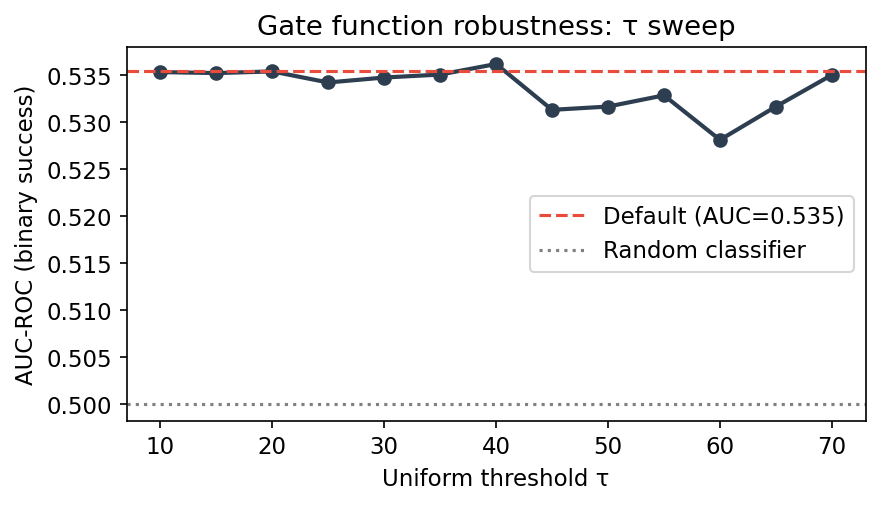

In [11]:
# Figure: tau sweep
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(tau_range), tau_aucs, 'o-', color='#2c3e50', linewidth=2)
ax.axhline(full_auc, color='#e74c3c', linestyle='--', label=f'Default (AUC={full_auc:.3f})')
ax.axhline(0.5, color='grey', linestyle=':', label='Random classifier')
ax.set_xlabel('Uniform threshold τ')
ax.set_ylabel('AUC-ROC (binary success)')
ax.set_title('Gate function robustness: τ sweep')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
fig.tight_layout()
fig.savefig(FIGURES / 'ablation_gate.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'ablation_gate.png', bbox_inches='tight')
plt.show()

## 7. Simple baselines

In [12]:
print('Simple baselines:')
print(f'  Random classifier       : 0.500')
for c, *_ in CATS:
    a = auc_mwu(df[f'cat_{c}_raw'], y)
    print(f'  {c} category alone        : {a:.3f}')

best_sub, best_sub_auc = '', 0.0
for col in sub_cols:
    a = auc_mwu(df[col], y)
    if a > best_sub_auc:
        best_sub_auc, best_sub = a, col
print(f'  Best single sub-metric ({best_sub}): {best_sub_auc:.3f}')

Simple baselines:
  Random classifier       : 0.500
  E category alone        : 0.503
  A category alone        : 0.518
  D category alone        : 0.515
  C category alone        : 0.539
  S category alone        : 0.611
  Best single sub-metric (sub_notebook_exec_order): 0.638


## 8. Rank stability (Table 4)

In [13]:
base_ranks = df['rrs'].rank()
rows = []
for cat, default_w, *_ in CATS:
    tau_vals = []
    for mult in np.linspace(0.5, 1.5, 20):
        new_w = default_w * mult
        others_scale = (1.0 - new_w) / (1.0 - default_w)
        w_scaled = {c: (w * others_scale if c != cat else new_w) for c, w, *__ in CATS}
        g_score = (
            sum(w_scaled[c] * gate(df[f'cat_{c}_raw'], t, k) * 100 for c, _w, t, k in CATS)
            - total_penalty
        )
        tau_val, _ = stats.kendalltau(base_ranks, np.clip(g_score, 0, 100))
        tau_vals.append(tau_val)
    rows.append({'Category': f'{cat} — {CAT_NAMES[cat]}',
                 'Min τ': round(min(tau_vals), 3),
                 'Mean τ': round(np.mean(tau_vals), 3),
                 'Max τ': round(max(tau_vals), 3)})

table4 = pd.DataFrame(rows).set_index('Category')
print('Table 4: Rank stability under ±50% weight perturbation')
table4

Table 4: Rank stability under ±50% weight perturbation


,Min τ,Mean τ,Max τ
Category,,,
E — Environment,0.911,0.961,0.998
A — Data Access.,0.942,0.972,0.996
D — Documentation,0.959,0.978,0.997
C — Code Quality,0.949,0.979,0.999
S — Repro. Signals,0.975,0.987,0.999


## 9. Grid search over weight simplex

In [14]:
grid_vals = [round(v, 1) for v in np.arange(0.1, 1.0, 0.1)]
best_auc_grid, best_weights = 0.0, None
all_aucs_grid = []
n_configs = 0

for wE in grid_vals:
    for wA in grid_vals:
        for wD in grid_vals:
            for wC in grid_vals:
                wS = round(1.0 - wE - wA - wD - wC, 8)
                if not (0.09 <= wS <= 0.91):
                    continue
                n_configs += 1
                g_score = (
                    wE * gate(df['cat_E_raw'], 40, 1.5) * 100
                    + wA * gate(df['cat_A_raw'], 30, 1.5) * 100
                    + wD * gate(df['cat_D_raw'], 20, 1.2) * 100
                    + wC * gate(df['cat_C_raw'], 25, 1.2) * 100
                    + wS * gate(df['cat_S_raw'], 30, 1.2) * 100
                    - total_penalty
                )
                a = auc_mwu(np.clip(g_score, 0, 100), y)
                all_aucs_grid.append(a)
                if a > best_auc_grid:
                    best_auc_grid = a
                    best_weights = dict(E=wE, A=wA, D=wD, C=wC, S=round(wS, 1))

print(f'Grid configurations : {n_configs}')
print(f'AUC range           : {min(all_aucs_grid):.3f} – {max(all_aucs_grid):.3f}  '
      f'(spread {max(all_aucs_grid)-min(all_aucs_grid):.3f})')
print(f'Best AUC            : {best_auc_grid:.3f}  at {best_weights}')
print(f'Default AUC         : {full_auc:.3f}')

Grid configurations : 126
AUC range           : 0.509 – 0.581  (spread 0.072)
Best AUC            : 0.581  at {'E': 0.1, 'A': 0.1, 'D': 0.1, 'C': 0.2, 'S': 0.5}
Default AUC         : 0.535


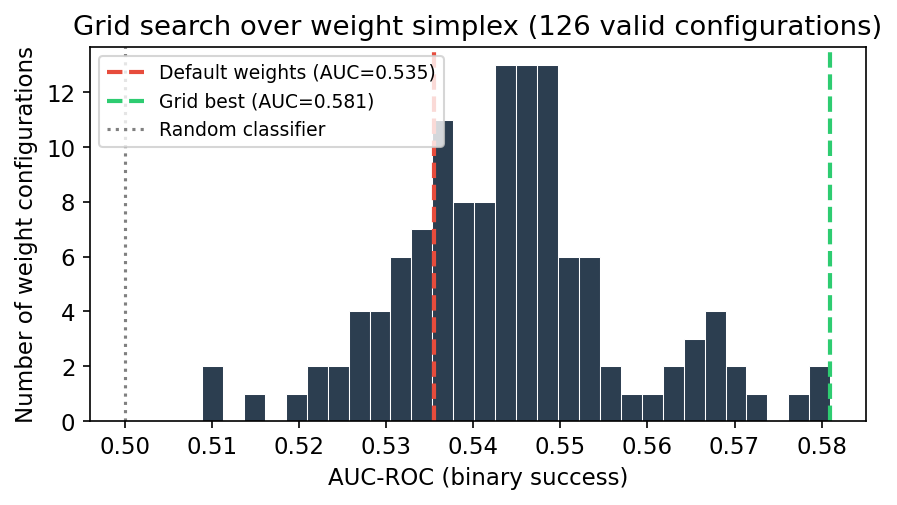

In [15]:
# Figure: grid search AUC histogram
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(all_aucs_grid, bins=30, color='#2c3e50', edgecolor='white', linewidth=0.5)
ax.axvline(full_auc, color='#e74c3c', linestyle='--', linewidth=2,
           label=f'Default weights (AUC={full_auc:.3f})')
ax.axvline(best_auc_grid, color='#2ecc71', linestyle='--', linewidth=2,
           label=f'Grid best (AUC={best_auc_grid:.3f})')
ax.axvline(0.5, color='grey', linestyle=':', label='Random classifier')
ax.set_xlabel('AUC-ROC (binary success)')
ax.set_ylabel('Number of weight configurations')
ax.set_title(f'Grid search over weight simplex ({n_configs} valid configurations)')
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / 'ablation_weight_search.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'ablation_weight_search.png', bbox_inches='tight')
plt.show()

## 10. Leave-One-Category-Out (LOCO) analysis (Table 5)

In [16]:
CAT_PENALTIES = {
    'E': df['penalty_E'], 'A': df['penalty_A'],
    'S': df['penalty_seed'],
    'D': pd.Series(np.zeros(len(df)), index=df.index),
    'C': pd.Series(np.zeros(len(df)), index=df.index),
}

rows = [{'Removed': 'None (full model)', 'AUC': full_auc, 'ΔAUC': float('nan')}]

for removed_cat, removed_w, *_ in CATS:
    gated_sum_renorm = (
        sum(df[f'cat_{c}_gated'] for c, w, *__ in CATS if c != removed_cat)
        / (1.0 - removed_w)
    )
    remaining_penalty = total_penalty - CAT_PENALTIES[removed_cat]
    rrs_loco = np.clip(gated_sum_renorm - remaining_penalty, 0, 100)
    a = auc_mwu(rrs_loco, y)
    rows.append({
        'Removed': f'−{removed_cat} ({CAT_NAMES[removed_cat]})',
        'AUC': round(a, 3),
        'ΔAUC': round(a - full_auc, 3),
    })

table5 = pd.DataFrame(rows).set_index('Removed')
print('Table 5: LOCO analysis')
print('(Positive ΔAUC = removing category improves binary AUC)')
table5

Table 5: LOCO analysis
(Positive ΔAUC = removing category improves binary AUC)


,AUC,ΔAUC
Removed,,
None (full model),0.535451,NaN
−E (Environment),0.563000,0.028
−A (Data Access.),0.556000,0.020
−D (Documentation),0.536000,0.001
−C (Code Quality),0.513000,-0.022
−S (Repro. Signals),0.514000,-0.022


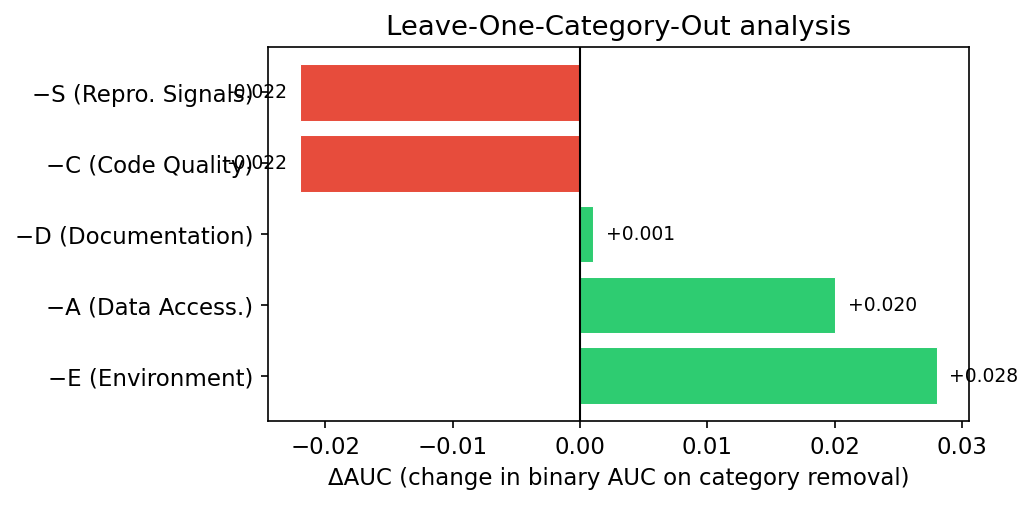

In [17]:
# Figure: LOCO tornado chart
loco_rows = [r for r in rows if r['Removed'] != 'None (full model)']
cats_loco = [r['Removed'] for r in loco_rows]
deltas = [r['ΔAUC'] for r in loco_rows]
colors = ['#2ecc71' if d > 0 else '#e74c3c' for d in deltas]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.barh(cats_loco, deltas, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('ΔAUC (change in binary AUC on category removal)')
ax.set_title('Leave-One-Category-Out analysis')
for bar, delta in zip(bars, deltas):
    ax.text(delta + 0.001 * np.sign(delta), bar.get_y() + bar.get_height()/2,
            f'{delta:+.3f}', va='center', ha='left' if delta >= 0 else 'right', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES / 'ablation_loco.pdf', bbox_inches='tight')
fig.savefig(FIGURES / 'ablation_loco.png', bbox_inches='tight')
plt.show()

## 11. Binary sub-metric count

In [18]:
binary_rows = []
for col in sub_cols:
    pct = ((df[col] == 0) | (df[col] == 100)).mean()
    binary_rows.append({'Sub-metric': col, 'Pct binary': round(pct, 3),
                        'Effectively binary': pct > 0.90})

bdf = pd.DataFrame(binary_rows).set_index('Sub-metric')
n_binary = bdf['Effectively binary'].sum()
print(f'Effectively binary sub-metrics (>90% repos return 0 or 100): {n_binary}/{len(sub_cols)}')
bdf

Effectively binary sub-metrics (>90% repos return 0 or 100): 10/26


,Pct binary,Effectively binary
Sub-metric,,
sub_ci_presence,1.000,True
sub_config_externalised,0.785,False
sub_container_spec,0.967,True
sub_data_acquisition_script,1.000,True
sub_data_description,0.704,False
sub_data_pointer,0.563,False
sub_dep_pinning,0.655,False
sub_doc_structure,0.648,False
sub_docstring_coverage,0.234,False


## 12. Summary — all paper statistics

In [19]:
print('=' * 60)
print('PAPER STATISTICS SUMMARY')
print('=' * 60)
print(f'N repos                  : {len(df)}')
print(f'Full RRS AUC             : {full_auc:.3f}  (expected: ~0.536)')
print(f'Grid best AUC            : {best_auc_grid:.3f}  (expected: ~0.581)')
print(f'Grid best weights        : {best_weights}')
print(f'Tau sweep range          : {max(tau_aucs)-min(tau_aucs):.3f}  (expected: ~0.008)')
print(f'Gate robustness range    : {abs(auc_linear - auc_strict):.3f}  (expected: ~0.000)')
print(f'Binary sub-metrics       : {n_binary}/26  (paper: 14/26)')

e_rpb, e_ppb = stats.pointbiserialr(df['cat_E_raw'], y)
e_groups = [df[df['failure_mode'] == m]['cat_E_raw'].values for m in FAILURE_MODES]
e_H, e_pkw = stats.kruskal(*e_groups)
print(f'E r_pb                   : {e_rpb:+.3f}  (expected: ~-0.014)')
print(f'E KW H                   : {e_H:.2f}  (expected: ~96.89)')
s_rpb, _ = stats.pointbiserialr(df['cat_S_raw'], y)
print(f'S r_pb                   : {s_rpb:+.3f}  (expected: ~+0.153)')
print('=' * 60)

PAPER STATISTICS SUMMARY
N repos                  : 423
Full RRS AUC             : 0.535  (expected: ~0.536)
Grid best AUC            : 0.581  (expected: ~0.581)
Grid best weights        : {'E': 0.1, 'A': 0.1, 'D': 0.1, 'C': 0.2, 'S': 0.5}
Tau sweep range          : 0.008  (expected: ~0.008)
Gate robustness range    : 0.001  (expected: ~0.000)
Binary sub-metrics       : 10/26  (paper: 14/26)
E r_pb                   : -0.014  (expected: ~-0.014)
E KW H                   : 96.89  (expected: ~96.89)
S r_pb                   : +0.152  (expected: ~+0.153)
